# 부산광역시 쓰레기 배출량 예측 pt.6

### : 종속변수 테스트

<br>

## 00. 기본 설정 

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact

# 경고 메시지는 출력 X
import warnings
warnings.filterwarnings("ignore")

In [142]:
# 한글 font 설정

import platform
import matplotlib.font_manager as fm

#matplotlib 패키지 한글 깨짐 처리
#------------------------------------------------------------------------------------
# 운영체제별 한글 폰트 설정

if platform.system() == 'Darwin':           # Mac 환경 폰트 설정
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':        # Windows 환경 폰트 설정
    plt.rc('font', family='Malgun Gothic')
    
plt.rcParams['axes.unicode_minus'] = False #한글 폰트 사용시 마이너스 폰트 깨짐 해결

In [143]:
# 글씨 선명하게 출력하는 설정

from IPython.display import set_matplotlib_formats
set_matplotlib_formats("retina")

<Axes: title={'center': '한글타이틀'}>

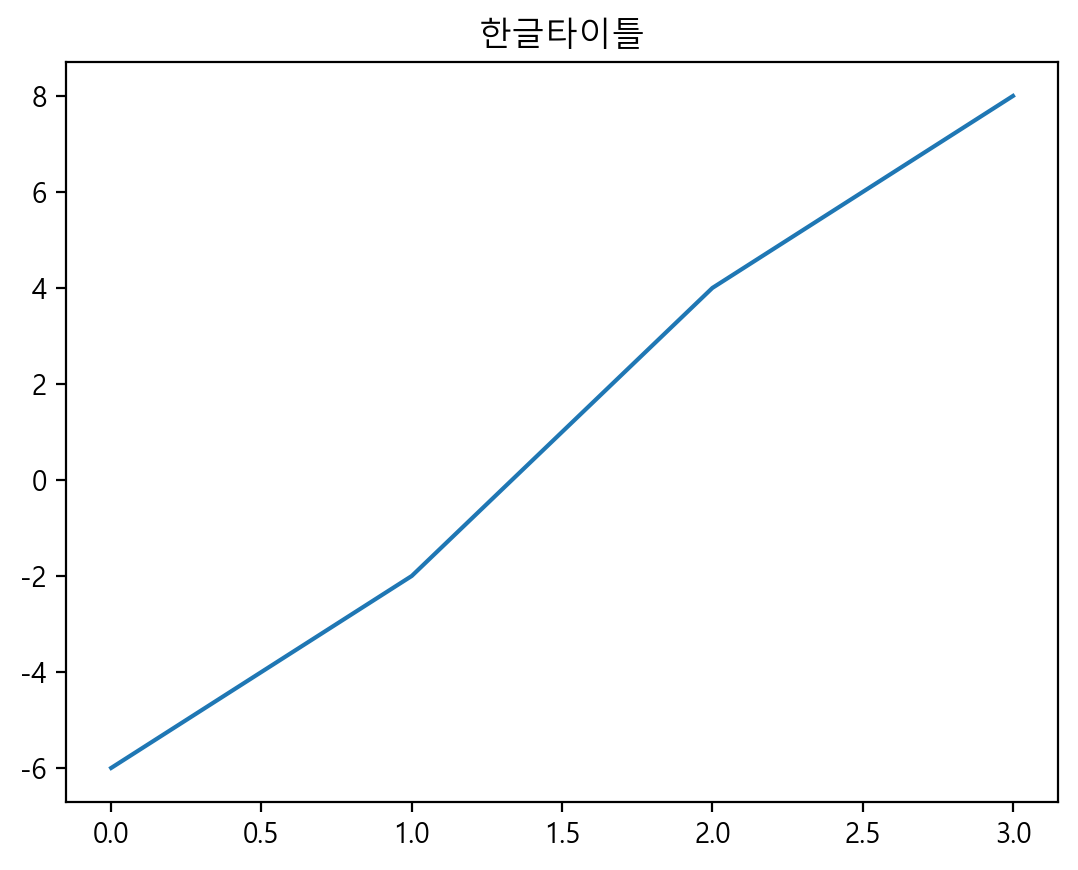

In [144]:
# 한글폰트와 마이너스 폰트 설정 확인
pd.Series([-6, -2, 4, 8]).plot(title="한글타이틀")

<br><br>

---
## 01. 데이터 불러오기

In [147]:
# 전처리된 폐기물 데이터
waste = pd.read_csv("data/폐기물데이터_행정구역변경_2.csv", encoding="cp949")

# 병합된 X변수 데이터
iv = pd.read_csv("data/x_전체변수병합.csv", encoding="cp949")

print(f"waste shape: {waste.shape}\n")
print(f"iv shape: {iv.shape}\n")
print(f"iv columns: {iv.columns}")

waste shape: (42365, 12)

iv shape: (1145, 24)

iv columns: Index(['행정구역', '시도', '시군구', '연도', '주민등록세대수', '총인구수', '단독주택-계', '아파트', '연립주택',
       '다세대주택', '비주거용 건물 내 주택', '단독주택비율', '아파트비율', '연립주택비율', '다세대주택비율',
       '비주거용주택비율', '1인가구', '2인가구', '3인가구', '4인가구', '5인이상가구', '총전입', '총전출',
       '순이동'],
      dtype='object')


<br><br>

---
## 02. 분석 목표 정의

<br>

> **종량제 방식으로 혼합 배출되었지만, '재활용' 처리된 양 예측하기**

- 혼합배출 → 분류작업 → 재활용 처리된 자원의 양
- **이중처리로 인한 추가 비용**이 발생한 자원량을 예측하는 것  

<br>

- `5_예측모델링`에서 종속변수를 **"`종량제방식 등 혼합배출`의 `가연성+불연성` 중 `재활용` 처리된 값** 을 썼는데,
- **랜덤포레스트 + 하이퍼파라미터 튜닝**을 한 결과 `R2 = 0.5416, MSE = 0.8977`라는 결과가 나왔음
- 그래서 종속변수 값을 **`가연성+불연성+건설폐재류 중 재활용 처리된 값`** 을 설정해서 다시 모델링 및 튜닝을 해보고자 함

<br>

### 추가
- 연도 변수 (one-hot encoding)

<br><br>

---
## 03. 폐기물 데이터 전처리

<br>

### 03-1. 종속변수 y값 정의하기
> 혼합배출된 종량제 폐기물 중에서 실제로 재활용 처리된 양의 총합을 종속변수로 설정 (가연성+불연성+건설폐재류 모두)
```
혼합배출_후_재활용량 = 
    폐기물_종류 == '종량제방식 등 혼합배출' AND
    '재활용' 컬럼의 값 합계
```

<br>

### 03-2. y값 계산
- 우선 폐기물_종류 == 종량제방식 등 혼합배출인 데이터 중 `재활용` 처리된 값의 합을 구하고
- 그 합계가 0 이상인 폐기물_종류2 목록을 출력해보기로

In [154]:
# 종량제방식 등 혼합배출 데이터프레임 필터링
filtered = waste[waste['폐기물_종류'] == '종량제방식 등 혼합배출'].reset_index(drop=True)
filtered.shape

(17175, 12)

In [156]:
# 폐기물_종류1 별 재활용량 합계
recycle_by_type = (
    filtered
    .groupby(['폐기물_종류1'])['재활용']
    .sum()
    .reset_index()
)

# 재활용량이 0 이상인 폐기물_종류2만 필터링
recycle_by_type = recycle_by_type[recycle_by_type['재활용'] > 0]
recycle_by_type

,폐기물_종류1,재활용
0,가연성,4835911.9
1,건설폐재류,360422.5
2,기타(배출불명등),36782.5
3,불연성,424053.0


위 표는 `종량제 방식`으로 혼합 배출된 폐기물 중에서 `재활용` 처리된 폐기물을 `폐기물_종류1`별로 집계한 결과임.

- 이 값은 **추가적인 인력/비용을 들여 재활용된 양** 의미
- 정책적 관점에서 **이중 처리된 재활용 자원**으로 볼 수 있으며, 예측의 타겟(Y값)이 될 것임

<br><br>


In [158]:
# 폐기물_종류1과 관계 없이 종량제방식 중 '재활용'된 값만 계산한 코드
target = (
    filtered
    .groupby(['행정구역', '연도'])['재활용']
    .sum()
    .reset_index()
    .rename(columns={'재활용': '혼합배출_후_재활용량'})
)
print(f"target_y shape (0-value 필터링 전): {target.shape}\n")
target.head()

target_y shape (0-value 필터링 전): (1145, 3)



,행정구역,연도,혼합배출_후_재활용량
0,강원_강릉시,2019,0.0
1,강원_강릉시,2020,0.0
2,강원_강릉시,2021,0.0
3,강원_강릉시,2022,0.0
4,강원_강릉시,2023,0.0


### 추가)
- 종속변수에 `건설폐재류`를 추가했을 경우와 추가하지 않았을 경우
    - 추가하지 않았을 경우, 같은 조건에서 선형회귀의 설명력이 약 `0.02` 정도 상승
    - 추가했을 경우, 같은 조건에서 랜덤포레스트의 설명력이 약 `0.09` 정도 감소

> **여기까지의 결과만으로 보자면, `건설폐재류`를 종속변수에 포함하는 것이 설명력 증가에 유리함!** (`기타`도 작은 값이니 그냥 추가)

In [171]:
print(f"y값(`혼합배출_후_재활용량`)이 0인 지역의 수: {len(target[target['혼합배출_후_재활용량']==0]['행정구역'].unique())}")
print(f"y값(`혼합배출_후_재활용량`)이 0인 행의 수: {target[target['혼합배출_후_재활용량'] == 0].shape[0]}")
target[target['혼합배출_후_재활용량']==0]['행정구역'].unique()

y값(`혼합배출_후_재활용량`)이 0인 지역의 수: 159
y값(`혼합배출_후_재활용량`)이 0인 행의 수: 555


array(['강원_강릉시', '강원_고성군', '강원_속초시', '강원_양양군', '강원_영월군', '강원_인제군',
       '강원_정선군', '강원_철원군', '강원_춘천시', '강원_태백시', '강원_평창군', '강원_화천군',
       '강원_횡성군', '경기_가평군', '경기_고양시', '경기_과천시', '경기_광명시', '경기_광주시',
       '경기_군포시', '경기_동두천시', '경기_성남시', '경기_수원시', '경기_시흥시', '경기_안산시',
       '경기_안성시', '경기_안양시', '경기_양평군', '경기_여주시', '경기_연천군', '경기_오산시',
       '경기_용인시', '경기_의왕시', '경기_의정부시', '경기_포천시', '경기_하남시', '경남_거제시',
       '경남_거창군', '경남_고성군', '경남_남해군', '경남_밀양시', '경남_사천시', '경남_산청군',
       '경남_양산시', '경남_진주시', '경남_창녕군', '경남_창원시', '경남_통영시', '경남_함안군',
       '경남_합천군', '경북_경주시', '경북_고령군', '경북_구미시', '경북_김천시', '경북_문경시',
       '경북_봉화군', '경북_상주시', '경북_성주군', '경북_안동시', '경북_영양군', '경북_영주시',
       '경북_예천군', '경북_울릉군', '경북_울진군', '경북_의성군', '경북_청도군', '경북_청송군',
       '경북_칠곡군', '대구_군위군', '서울_강남구', '서울_강동구', '서울_강서구', '서울_관악구',
       '서울_광진구', '서울_구로구', '서울_금천구', '서울_도봉구', '서울_동대문구', '서울_동작구',
       '서울_마포구', '서울_서대문구', '서울_서초구', '서울_성동구', '서울_성북구', '서울_송파구',
       '서울_영등포구', '서울_은평구', '서울_종로구', '서울_중구', '서울_중랑구', '

<br>

### 03-3. `혼합배출_후_재활용량`이 0인 행을 삭제 하기 전 iv 데이터프레임과 병합

In [173]:
print(target.shape)
print(iv.shape)

(1145, 3)
(1145, 24)


In [174]:
# target: 종속변수, iv: 독립변수
merged = pd.merge(target, iv, on=['행정구역', '연도'], how='left')
print(merged.shape)
merged.head(3)

(1145, 25)


,행정구역,연도,혼합배출_후_재활용량,시도,시군구,주민등록세대수,총인구수,단독주택-계,아파트,연립주택,...,다세대주택비율,비주거용주택비율,1인가구,2인가구,3인가구,4인가구,5인이상가구,총전입,총전출,순이동
0,강원_강릉시,2019,0.0,강원,강릉시,99086,213442,29481,50175,2919,...,0.0171,0.0202,32119,28629,16547,11083,3715.0,31980,30787,1193
1,강원_강릉시,2020,0.0,강원,강릉시,101424,213321,29549,51631,3161,...,0.0167,0.0202,37635,29649,16499,10810,3439.0,31595,30983,612
2,강원_강릉시,2021,0.0,강원,강릉시,102879,212965,29625,53159,3212,...,0.0164,0.0201,38581,30768,16191,10369,3196.0,31820,30668,1152


In [175]:
merged.columns

Index(['행정구역', '연도', '혼합배출_후_재활용량', '시도', '시군구', '주민등록세대수', '총인구수', '단독주택-계',
       '아파트', '연립주택', '다세대주택', '비주거용 건물 내 주택', '단독주택비율', '아파트비율', '연립주택비율',
       '다세대주택비율', '비주거용주택비율', '1인가구', '2인가구', '3인가구', '4인가구', '5인이상가구', '총전입',
       '총전출', '순이동'],
      dtype='object')

<br><br>

---

### 03-4. `혼합배출 후 재활용량`의 결측치 처리
- 전체 데이터를 기준으로, 159개의 지역에는 특정 연도에 `혼합배출_후_재활용량`이 **전혀 없거나 0**인 경우가 있음
- 아래와 같은 경우일 수 있다:
    - 실제로 `종량제방식`에서 재활용 처리가 이루어지지 않음
    - 관련 데이터가 측정되지 않음
    - 혼합배출 쓰레기를 따로 재활용 처리하지 않고 소각/매립하는 시스템을 가진 지역
    
<br>

> 모델링 결과가 안 좋게 나올 수 있고, **"이중 처리로 인한 추가 비용이 발생하지 않은"** 케이스이므로 우선 `Y=0`인 행 제거

In [177]:
# merged에 포함된 행정구역 수 확인
print(f"merged 내 고유 행정구역 수: {merged['행정구역'].nunique()}")

# 혼합배출_후_재활용량 == 0인 행정구역만 따로
zero_recycle_regions = target[target['혼합배출_후_재활용량'] == 0]['행정구역'].unique()

# merged에서 해당 지역만 필터링
merged_zero_rows = merged[
    (merged['행정구역'].isin(zero_recycle_regions)) &
    (merged['혼합배출_후_재활용량'] == 0)
]
print(f"merged 내 y=0인 행의 수: {merged_zero_rows.shape[0]}")

merged 내 고유 행정구역 수: 229
merged 내 y=0인 행의 수: 555


In [180]:
merged = merged[merged['혼합배출_후_재활용량'] > 0].reset_index(drop=True)
print(f"혼합배출 후 재활용량을 제거한 후의 merged 데이터프레임: {merged.shape}")
merged.head(3)

# 가연성+불연성만 따졌을 때보다 18개의 행이 많아짐 (1145 - 555)

혼합배출 후 재활용량을 제거한 후의 merged 데이터프레임: (590, 25)


,행정구역,연도,혼합배출_후_재활용량,시도,시군구,주민등록세대수,총인구수,단독주택-계,아파트,연립주택,...,다세대주택비율,비주거용주택비율,1인가구,2인가구,3인가구,4인가구,5인이상가구,총전입,총전출,순이동
0,강원_고성군,2022,2863.8,강원,고성군,15291,27274,9011,3478,153,...,0.0115,0.0281,4755,4494,1774,920,366.0,3269,2968,301
1,강원_고성군,2023,2467.3,강원,고성군,15431,27305,9021,3495,153,...,0.0114,0.0280,5348,4552,1729,914,323.0,3262,2989,273
2,강원_동해시,2019,4818.0,강원,동해시,41141,90522,10461,24961,1657,...,0.0296,0.0173,10543,12086,7172,4833,1580.0,10516,11039,-523


<br><br>



### 03-5. `target` 데이터의 기초 통계 확인

In [181]:
merged['혼합배출_후_재활용량'].describe()

count      590.000000
mean      9588.423559
std      12147.345864
min          9.200000
25%       1997.900000
50%       5746.450000
75%      12456.925000
max      99404.800000
Name: 혼합배출_후_재활용량, dtype: float64

> 평균(9588.423559)보다 표준편차(12147.345864)가 커서 **우측으로 긴 꼬리를 가진 비대칭 분포**일 가능성이 큼

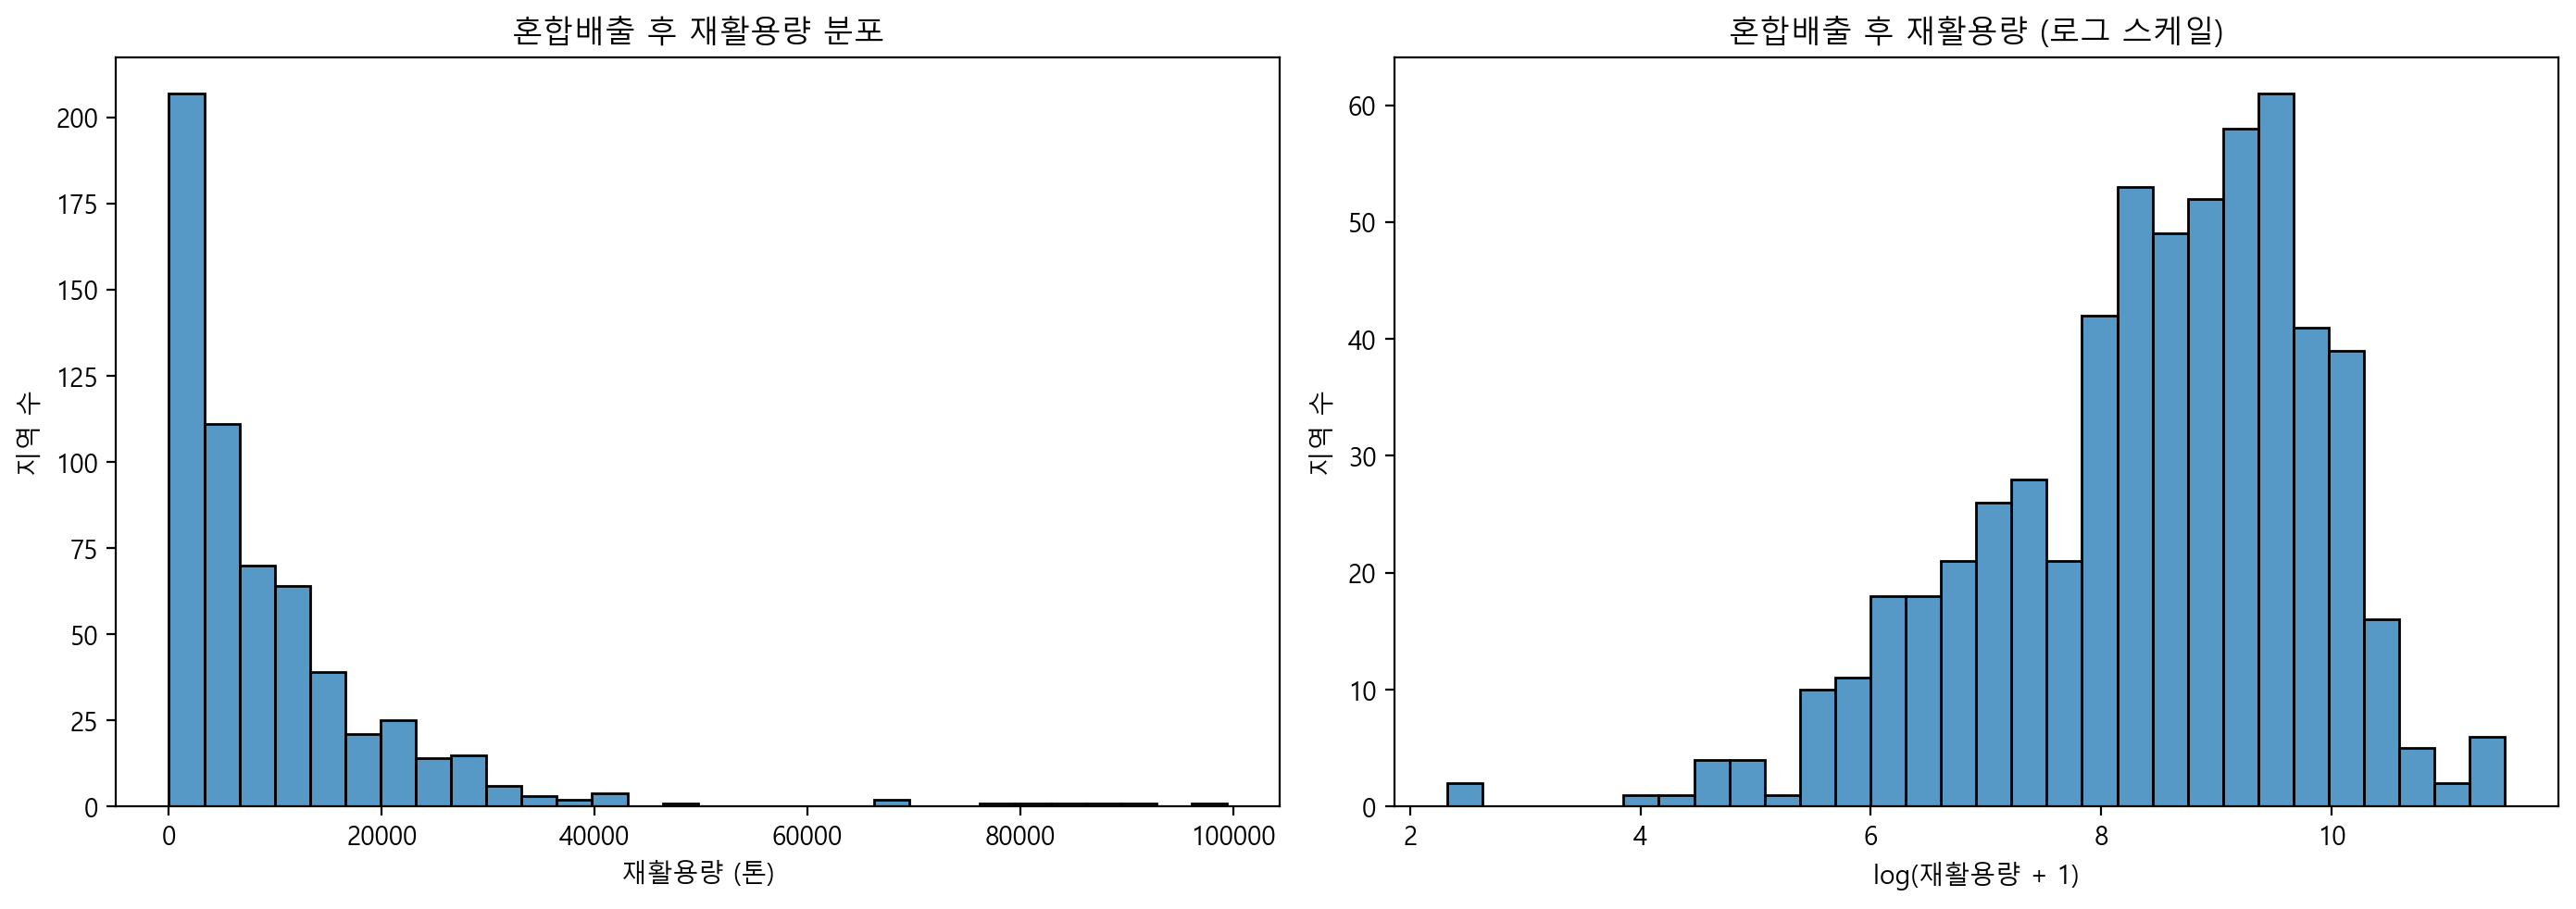

In [182]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 원래 값 분포
sns.histplot(
    data=merged,
    x='혼합배출_후_재활용량',
    bins=30,
    edgecolor='black',
    ax=axes[0],
)
axes[0].set_title('혼합배출 후 재활용량 분포')
axes[0].set_xlabel('재활용량 (톤)')
axes[0].set_ylabel('지역 수')

# 로그 변환 분포
sns.histplot(
    x=np.log1p(merged['혼합배출_후_재활용량']),
    bins=30,
    edgecolor='black',
    ax=axes[1]
)
axes[1].set_title('혼합배출 후 재활용량 (로그 스케일)')
axes[1].set_xlabel('log(재활용량 + 1)')
axes[1].set_ylabel('지역 수')

plt.tight_layout()

- 모델에는 log_혼합배출_후_재활용량을 사용하고
- 예측 후에는 `np.expm1()`으로 **원래 스케일(톤 단위)** 로 다시 바꾸기

In [183]:
# Y값을 로그 변환한 컬럼 추가
merged['log_혼합배출_후_재활용량'] = np.log1p(merged['혼합배출_후_재활용량'])
merged[['혼합배출_후_재활용량', 'log_혼합배출_후_재활용량']].describe()

,혼합배출_후_재활용량,log_혼합배출_후_재활용량
count,590.000000,590.000000
mean,9588.423559,8.435127
std,12147.345864,1.406751
min,9.200000,2.322388
25%,1997.900000,7.600347
50%,5746.450000,8.656509
75%,12456.925000,9.430111
max,99404.800000,11.506966


### 이상치 처리 할말?
- 로그 변환한 걸 DV로 사용하기로 했으니 이상치 처리는 안 하는 게 맞을 거 같다!
- 트리 기반 모델에서는 **이상치가 존재해도 전체 모델 학습에 거의 영향이 없으니** 이상치 처리를 따로 하지 않아도 됨
- 오히려 이상치를 유지함으로써 **높은 배출량을 가진 지역도 함께 학습**됨

Text(0.5, 1.0, '로그 스케일 boxplot')

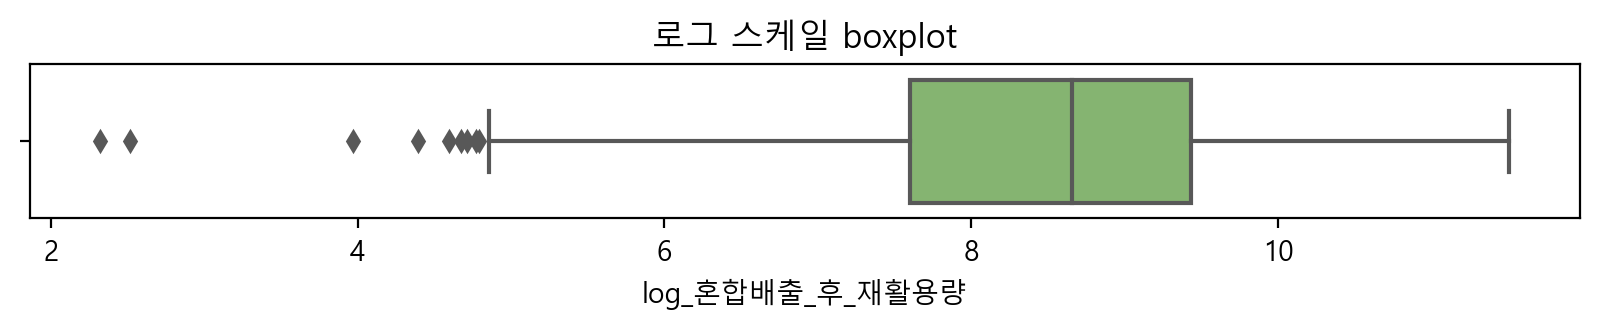

In [184]:
# 그래도 boxplot은 그려보기
plt.figure(figsize=(10, 1))
sns.boxplot(x=merged['log_혼합배출_후_재활용량'], palette = 'summer')
plt.title('로그 스케일 boxplot')

<br><br>

---

### 03-6. 추가 시각화

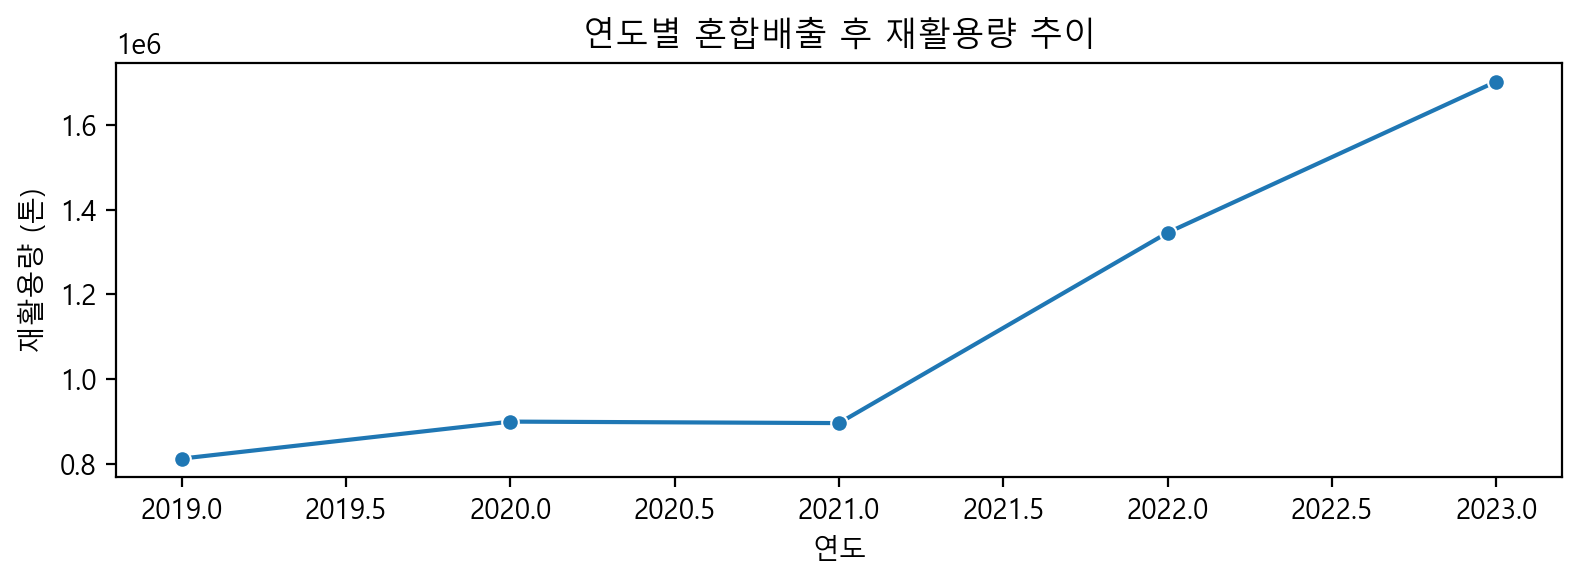

In [187]:
# 연도별 합계
yearly = merged.groupby('연도')['혼합배출_후_재활용량'].sum().reset_index()

plt.figure(figsize=(8, 3))
sns.lineplot(data=yearly, x='연도', y='혼합배출_후_재활용량', marker='o')
plt.title('연도별 혼합배출 후 재활용량 추이')
plt.xlabel('연도')
plt.ylabel('재활용량 (톤)')
plt.tight_layout()

In [188]:
yearly

,연도,혼합배출_후_재활용량
0,2019,812891.5
1,2020,900093.2
2,2021,896600.7
3,2022,1345621.0
4,2023,1701963.5


### 연도별 혼합배출 재활용량 증가 추세 (`혼합배출_후_재활용량` > 0인 지역만)
- 2019년 `812891.5` → 2023년 `1701963.5` (두 배 이상 증가)
- 해석
    - 이는 사람들의 **분리배출 실패가 늘었거나**
    - **분류 시스템이 개선되어 더 많이 선별/재활용**되었거나
    - **혼합배출량 자체가 증가**했을 가능성이 있음
> 이 추세는 정책적으로 **이중 처리**로 인한 비용이 급증하고 있을 수 있음을 의미함.
> → 혼합배출량이 아니라 **“혼합된 것 중 재활용된 양”** 이니까 **처리 시스템 부담 증가**로 해석할 수 있을 듯

<br>

### "혼합배출이 많다 != 시민 참여가 낮다" → 혼합배출은 많지만, 잘 선별해서 재활용하는 시스템이 있기 때문일 수도

> 혼합배출이 많고 재활용량이 많은 지역은 “후처리 부담 지역”, 반대로 혼합배출이 적고 재활용도 적은 지역은 **“무관심/측정 누락 가능성”**으로 분류 가능함

<br>

### 연도 feature를 모델에 추가하면?
- 종속 변수가 연도에 따라 뚜렷한 경향성을 보이는 상황이니 연도 정보를 모델에 독립 변수로 넣어주는 게 좋을 것 같다는 판단

<br><br>

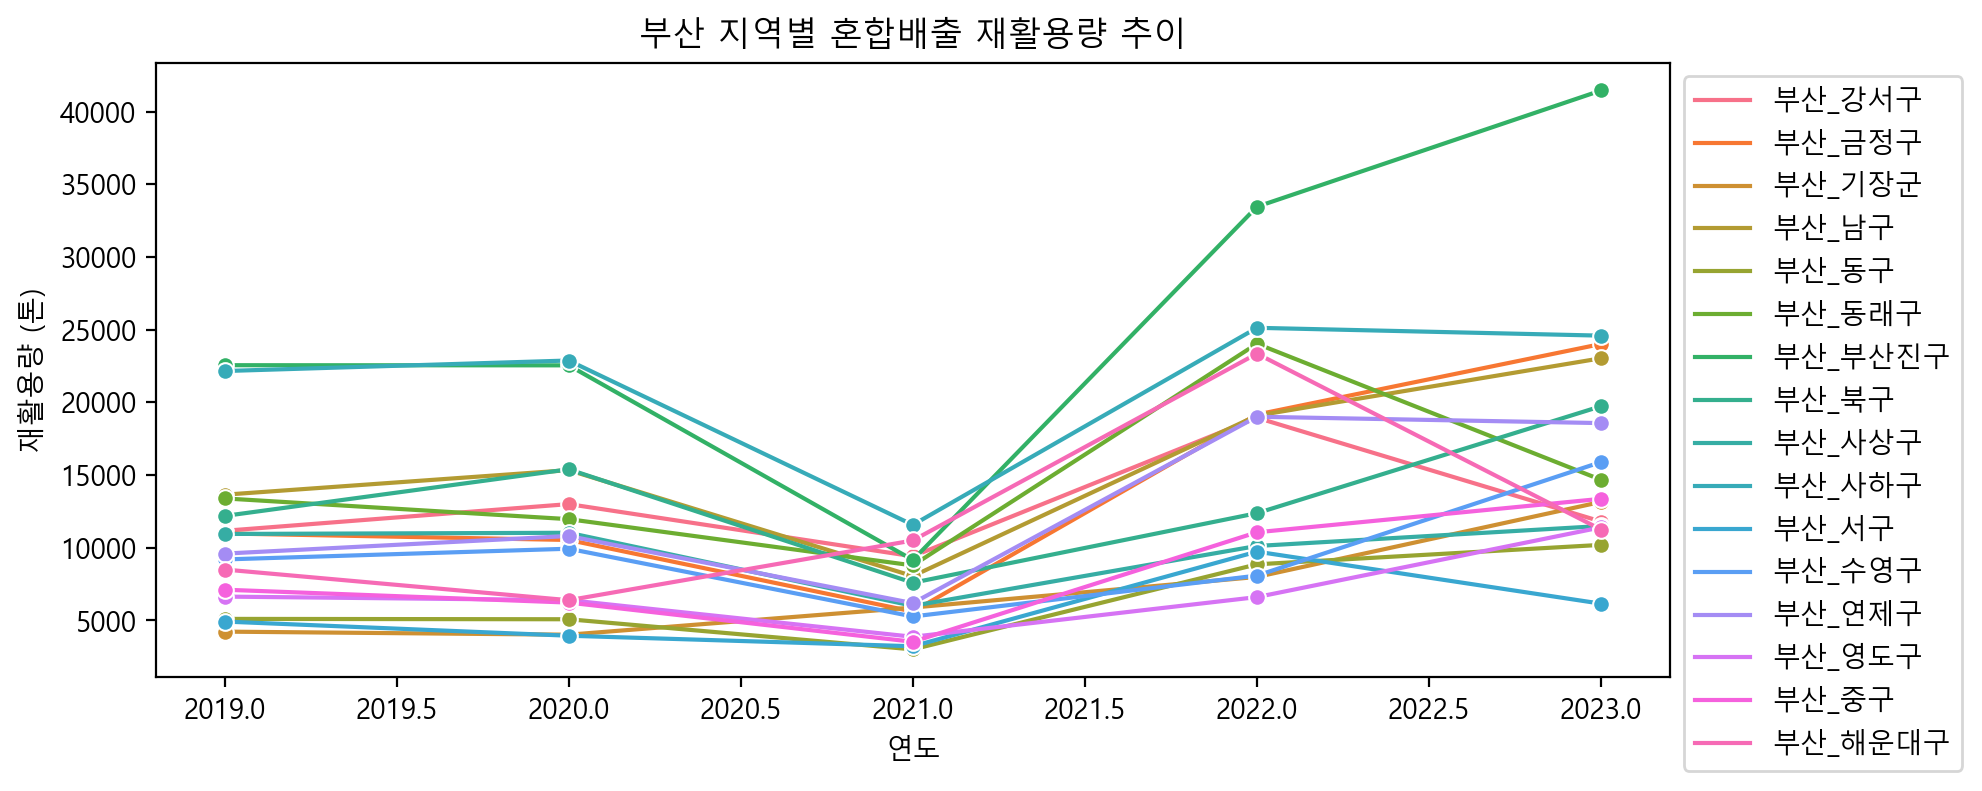

In [189]:
# 부산광역시 관련 지역만 보기
busan = merged[merged['행정구역'].str.startswith('부산')]

plt.figure(figsize=(10, 4))
sns.lineplot(data=busan, x='연도', y='혼합배출_후_재활용량', hue='행정구역', marker='o')
plt.title('부산 지역별 혼합배출 재활용량 추이')
plt.xlabel('연도')
plt.ylabel('재활용량 (톤)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()

<br><br>

---
## 04. 독립변수 전처리
- 가구원수 별 가구 수, 주택 종류별 주택 수 컬럼은 비율을 사용
- 상관관계가 높은 변수는 하나만 선택하기

<br>

### 04-1. 비율 변수로 변경 (`가구원수 별 가구 수`, `주택 종류별 주택 수`) & col 삭제

In [190]:
merged_processed = merged.copy()

# 가구 비율 컬럼 추가
for col in ['1인가구', '2인가구', '3인가구', '4인가구', '5인이상가구']:
    merged_processed[f'{col}_비율'] = merged_processed[col] / (merged_processed[['1인가구', '2인가구', '3인가구', '4인가구', '5인이상가구']].sum(axis=1))

merged_processed.head(1)

,행정구역,연도,혼합배출_후_재활용량,시도,시군구,주민등록세대수,총인구수,단독주택-계,아파트,연립주택,...,5인이상가구,총전입,총전출,순이동,log_혼합배출_후_재활용량,1인가구_비율,2인가구_비율,3인가구_비율,4인가구_비율,5인이상가구_비율
0,강원_고성군,2022,2863.8,강원,고성군,15291,27274,9011,3478,153,...,366.0,3269,2968,301,7.960254,0.386303,0.365099,0.144122,0.074742,0.029734


In [191]:
# 사용하지 않을 칼럼 삭제
cols_to_drop = [
    '1인가구', '2인가구', '3인가구', '4인가구', '5인이상가구',
    '단독주택-계', '아파트', '연립주택', '다세대주택', '비주거용 건물 내 주택'
]
merged_processed = merged_processed.drop(columns=cols_to_drop)
print(merged_processed.shape)
print(merged_processed.columns)

(590, 21)
Index(['행정구역', '연도', '혼합배출_후_재활용량', '시도', '시군구', '주민등록세대수', '총인구수', '단독주택비율',
       '아파트비율', '연립주택비율', '다세대주택비율', '비주거용주택비율', '총전입', '총전출', '순이동',
       'log_혼합배출_후_재활용량', '1인가구_비율', '2인가구_비율', '3인가구_비율', '4인가구_비율',
       '5인이상가구_비율'],
      dtype='object')




<br>

### 04-2. 연도 변수 원-핫 인코딩

In [192]:
from pandas.api.types import is_bool_dtype

In [193]:
merged_encoded = pd.get_dummies(merged_processed, columns=['연도'], prefix='연도')
print(f"one-hot encoding 후 merged_encoded shape: {merged_encoded.shape}")
print(f"merged_encoded cols:\n{merged_encoded.columns.tolist()}\n")

one-hot encoding 후 merged_encoded shape: (590, 25)
merged_encoded cols:
['행정구역', '혼합배출_후_재활용량', '시도', '시군구', '주민등록세대수', '총인구수', '단독주택비율', '아파트비율', '연립주택비율', '다세대주택비율', '비주거용주택비율', '총전입', '총전출', '순이동', 'log_혼합배출_후_재활용량', '1인가구_비율', '2인가구_비율', '3인가구_비율', '4인가구_비율', '5인이상가구_비율', '연도_2019', '연도_2020', '연도_2021', '연도_2022', '연도_2023']



In [194]:
for col in merged_encoded.columns:
    if col.startswith('연도_') and is_bool_dtype(merged_encoded[col]):
        merged_encoded[col] = merged_encoded[col].astype(int)

merged_encoded.head(1)

,행정구역,혼합배출_후_재활용량,시도,시군구,주민등록세대수,총인구수,단독주택비율,아파트비율,연립주택비율,다세대주택비율,...,1인가구_비율,2인가구_비율,3인가구_비율,4인가구_비율,5인이상가구_비율,연도_2019,연도_2020,연도_2021,연도_2022,연도_2023
0,강원_고성군,2863.8,강원,고성군,15291,27274,0.6845,0.2642,0.0116,0.0115,...,0.386303,0.365099,0.144122,0.074742,0.029734,0,0,0,1,0


In [197]:
# 모델학습에 사용할 최종 데이터프레임 저장
# merged_encoded.to_csv("data/최종_모델학습용.csv", encoding='cp949', index=False)


<br>

### 04-2. 독립변수 기본 통계 확인

In [198]:
merged_encoded.describe()

,혼합배출_후_재활용량,주민등록세대수,총인구수,단독주택비율,아파트비율,연립주택비율,다세대주택비율,비주거용주택비율,총전입,총전출,...,1인가구_비율,2인가구_비율,3인가구_비율,4인가구_비율,5인이상가구_비율,연도_2019,연도_2020,연도_2021,연도_2022,연도_2023
count,590.000000,5.900000e+02,5.900000e+02,590.000000,590.000000,590.000000,590.000000,590.000000,590.000000,590.000000,...,590.000000,590.000000,590.000000,590.000000,590.000000,590.000000,590.000000,590.000000,590.000000,590.000000
mean,9588.423559,1.282476e+05,2.866771e+05,0.305954,0.553027,0.027173,0.100656,0.013188,34480.259322,34075.071186,...,0.345111,0.304024,0.183712,0.128133,0.039021,0.183051,0.189831,0.186441,0.220339,0.220339
std,12147.345864,1.443322e+05,3.374046e+05,0.260262,0.239655,0.016030,0.101276,0.006880,31271.489321,29619.376409,...,0.057693,0.041584,0.031294,0.041712,0.009697,0.387036,0.392500,0.389792,0.414827,0.414827
min,9.200000,1.054400e+04,2.105600e+04,0.025700,0.001200,0.006000,0.002400,0.002200,1790.000000,1698.000000,...,0.179554,0.215742,0.115086,0.047513,0.014374,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1997.900000,3.859125e+04,7.947825e+04,0.116850,0.364525,0.015400,0.024200,0.008400,9081.250000,9247.750000,...,0.307244,0.272112,0.158885,0.094600,0.031952,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5746.450000,1.007100e+05,2.180770e+05,0.180650,0.619250,0.024350,0.058150,0.011700,27986.500000,28097.500000,...,0.348395,0.293665,0.183515,0.126540,0.037964,0.000000,0.000000,0.000000,0.000000,0.000000
75%,12456.925000,1.713508e+05,3.867200e+05,0.458175,0.758300,0.035700,0.140675,0.016750,52127.250000,53788.250000,...,0.383186,0.338702,0.208120,0.160545,0.045259,0.000000,0.000000,0.000000,0.000000,0.000000
max,99404.800000,1.074156e+06,2.394514e+06,0.974700,0.916200,0.123700,0.461200,0.047100,168445.000000,162228.000000,...,0.572813,0.401841,0.272435,0.239124,0.077452,1.000000,1.000000,1.000000,1.000000,1.000000


In [199]:
merged_encoded.columns

Index(['행정구역', '혼합배출_후_재활용량', '시도', '시군구', '주민등록세대수', '총인구수', '단독주택비율',
       '아파트비율', '연립주택비율', '다세대주택비율', '비주거용주택비율', '총전입', '총전출', '순이동',
       'log_혼합배출_후_재활용량', '1인가구_비율', '2인가구_비율', '3인가구_비율', '4인가구_비율',
       '5인이상가구_비율', '연도_2019', '연도_2020', '연도_2021', '연도_2022', '연도_2023'],
      dtype='object')

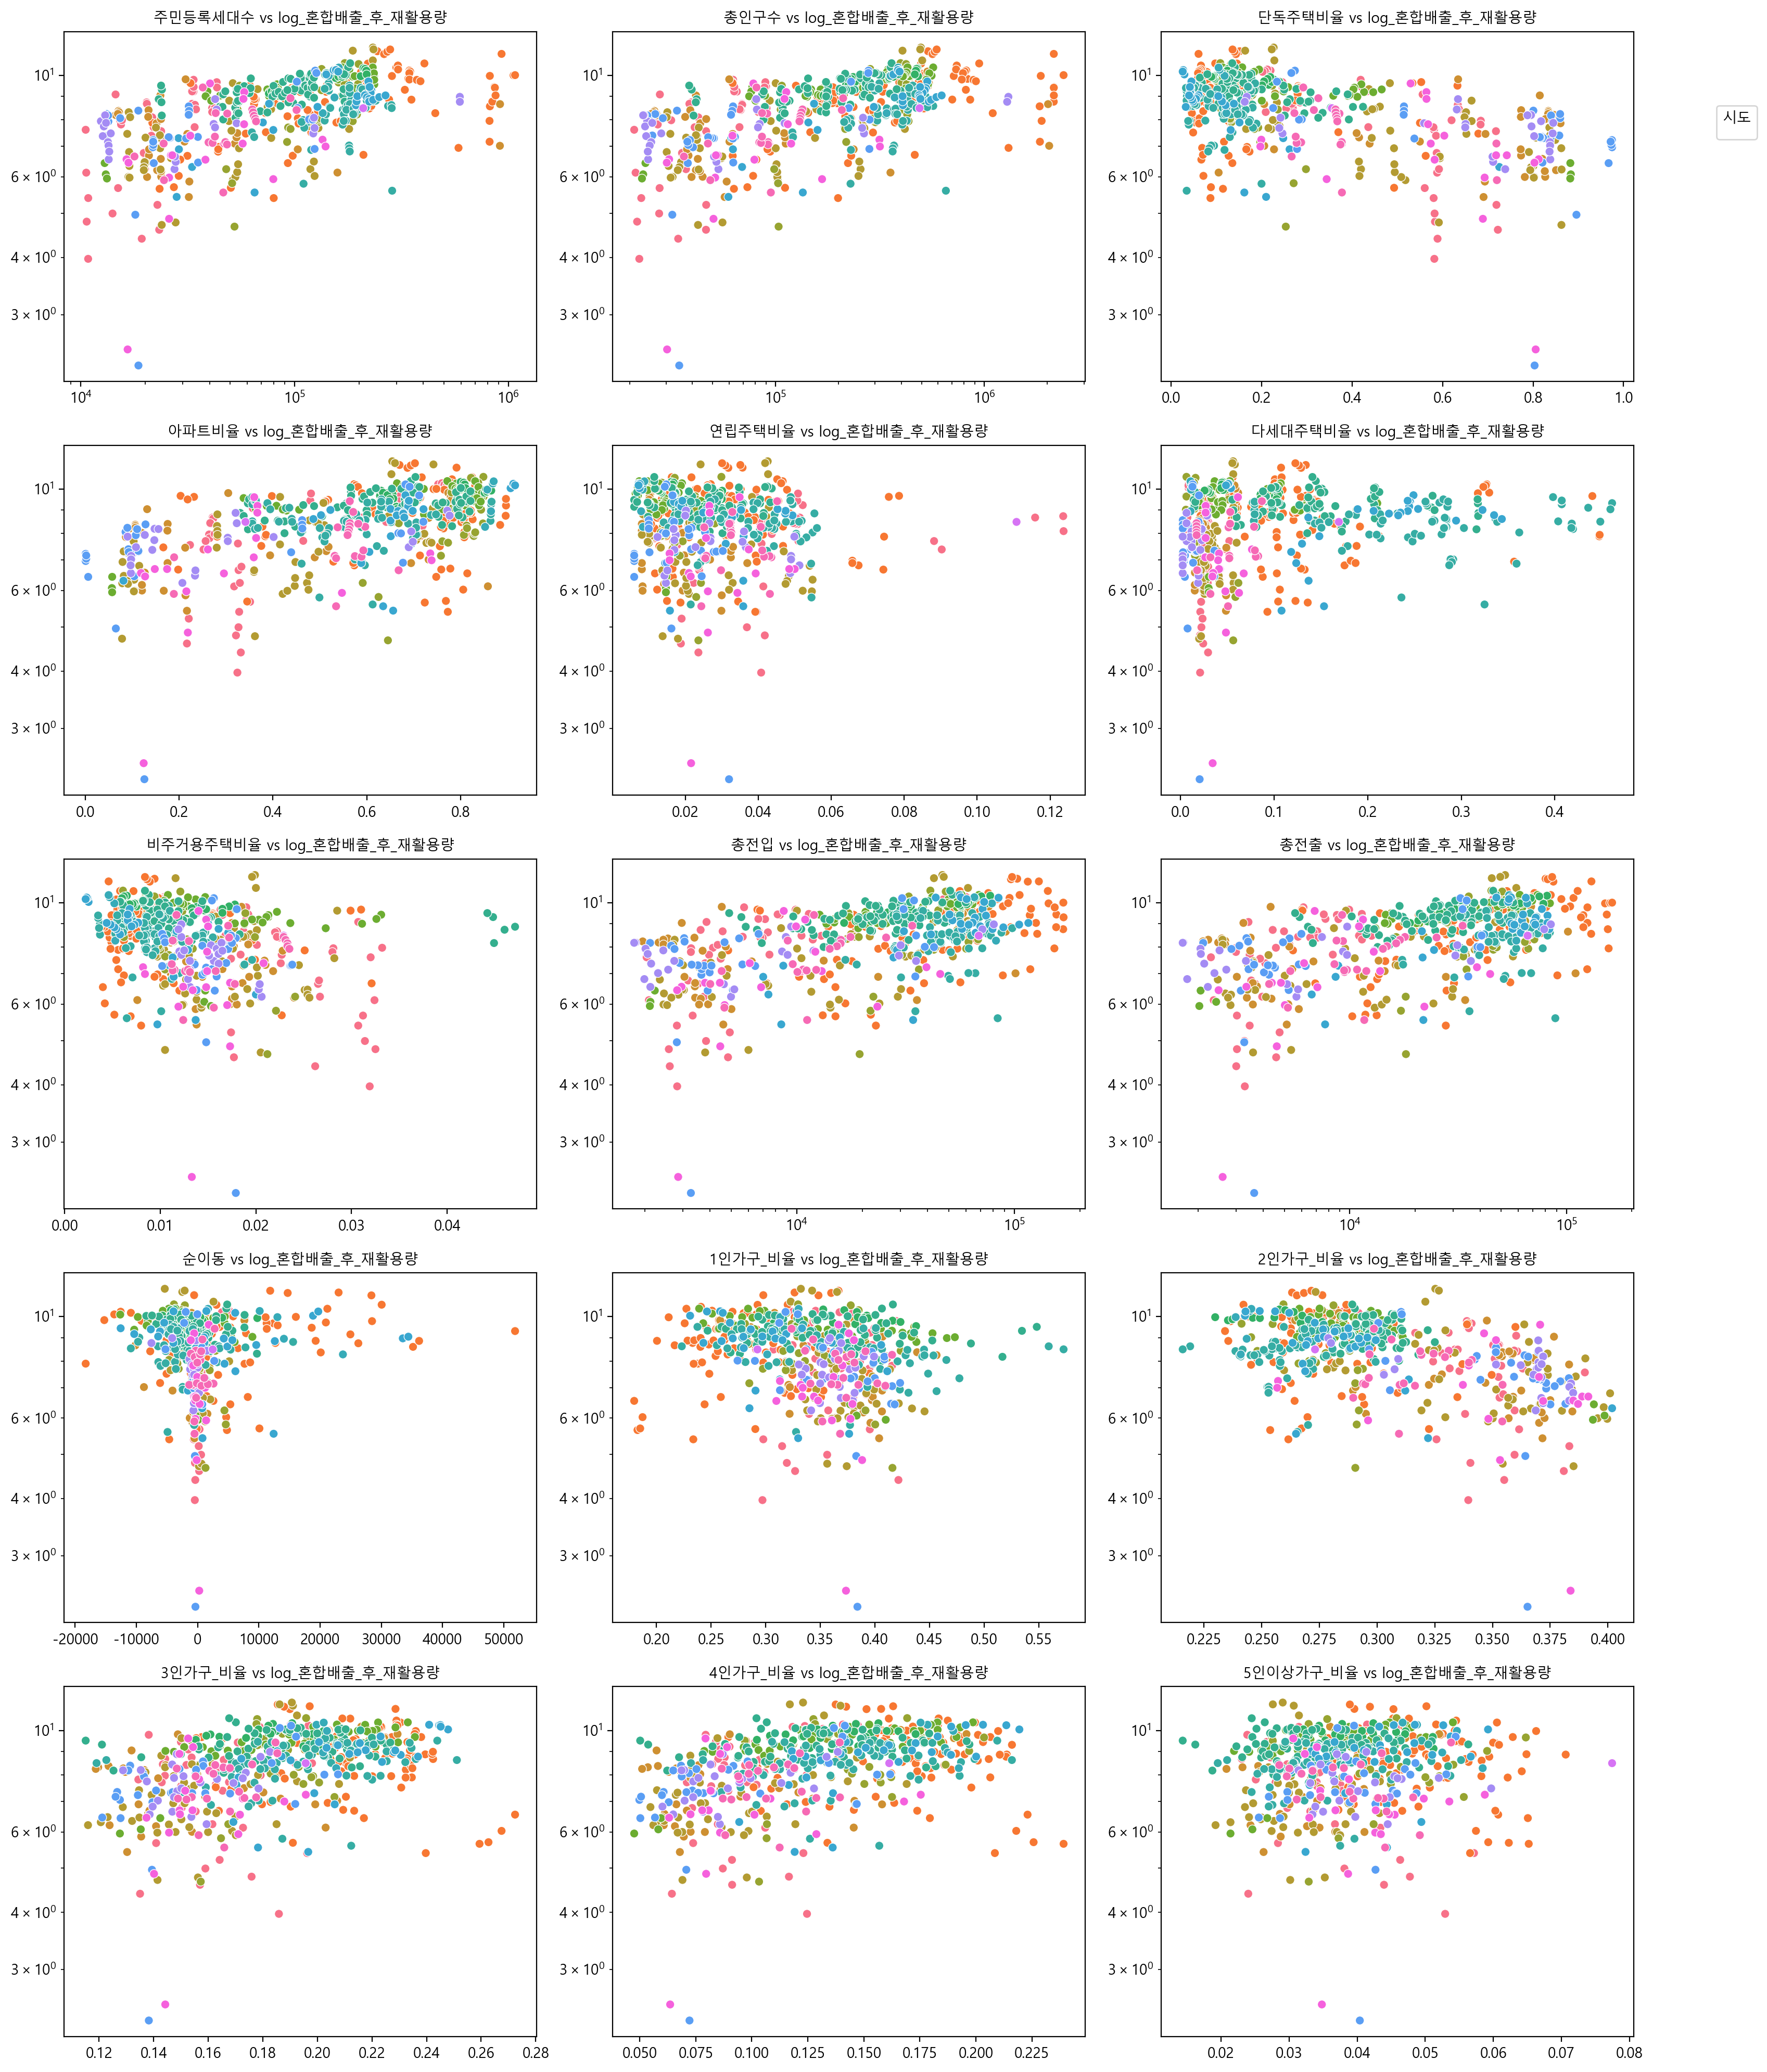

In [200]:
# x축 변수
x_columns = ['주민등록세대수', '총인구수', '단독주택비율','아파트비율', '연립주택비율', '다세대주택비율', '비주거용주택비율', '총전입',
             '총전출', '순이동', '1인가구_비율', '2인가구_비율', '3인가구_비율', '4인가구_비율', '5인이상가구_비율']
y_column = 'log_혼합배출_후_재활용량'

# 서브플롯: 5행 3열
fig, axes = plt.subplots(5, 3, figsize=(16, 20))
axes = axes.flatten()

for i, x_col in enumerate(x_columns):
    ax = axes[i]
    sns.scatterplot(
        data=merged_encoded,
        x=x_col,
        y=y_column,
        hue='시도',
        ax=ax,
        legend=False
    )
    # 로그스케일 적용 조건
    if x_col in ['주민등록세대수', '총인구수', '총전입', '총전출']:
        ax.set_xscale('log')
    ax.set_yscale('log')

    ax.set_title(f'{x_col} vs {y_column}', fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')

    handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.03, 0.95), loc='upper left', title='시도')
plt.tight_layout()

- 트리 모델에서는 스케일링이 필요하진 않지만
- 선형회귀에서는 필요하므로 일단 `['주민등록세대수', '총인구수', '총전입', '총전출']` 칼럼에 대해 로그스케일을 적용시켜보겠음
- `'순이동'`은 양수-음수의 범위이므로 일단 그대로 두기

<br>

### 04-3. 독립변수 스케일링

In [201]:
# 로그 스케일로 변환할 칼럼
cols_log = ['주민등록세대수', '총인구수', '총전입', '총전출']

merged_log = merged_encoded.copy()

# np.log1p()로 변환하여 새로운 칼럼 만듦
for col in cols_log:
    merged_log[col + '_log'] = np.log1p(merged_log[col])
    
# 원본 칼럼 삭제
merged_log = merged_log.drop(columns=cols_log)

# 새 데이터프레임(merged_log)에는 로그 변환된 칼럼만 존재
print(merged_log.columns)
merged_log.head(1)

Index(['행정구역', '혼합배출_후_재활용량', '시도', '시군구', '단독주택비율', '아파트비율', '연립주택비율',
       '다세대주택비율', '비주거용주택비율', '순이동', 'log_혼합배출_후_재활용량', '1인가구_비율', '2인가구_비율',
       '3인가구_비율', '4인가구_비율', '5인이상가구_비율', '연도_2019', '연도_2020', '연도_2021',
       '연도_2022', '연도_2023', '주민등록세대수_log', '총인구수_log', '총전입_log', '총전출_log'],
      dtype='object')


,행정구역,혼합배출_후_재활용량,시도,시군구,단독주택비율,아파트비율,연립주택비율,다세대주택비율,비주거용주택비율,순이동,...,5인이상가구_비율,연도_2019,연도_2020,연도_2021,연도_2022,연도_2023,주민등록세대수_log,총인구수_log,총전입_log,총전출_log
0,강원_고성군,2863.8,강원,고성군,0.6845,0.2642,0.0116,0.0115,0.0281,301,...,0.029734,0,0,0,1,0,9.635085,10.213726,8.092545,7.99598



<br>

### 04-4. 상관관계 확인

In [202]:
from matplotlib.patches import Rectangle

In [203]:
cols = ['혼합배출_후_재활용량', '단독주택비율', '아파트비율', '연립주택비율', '다세대주택비율', '비주거용주택비율', '순이동',
        'log_혼합배출_후_재활용량', '1인가구_비율', '2인가구_비율', '3인가구_비율',  '4인가구_비율', '5인이상가구_비율',
        '주민등록세대수_log', '총인구수_log', '총전입_log', '총전출_log',
        '연도_2019', '연도_2020', '연도_2021', '연도_2022', '연도_2023']

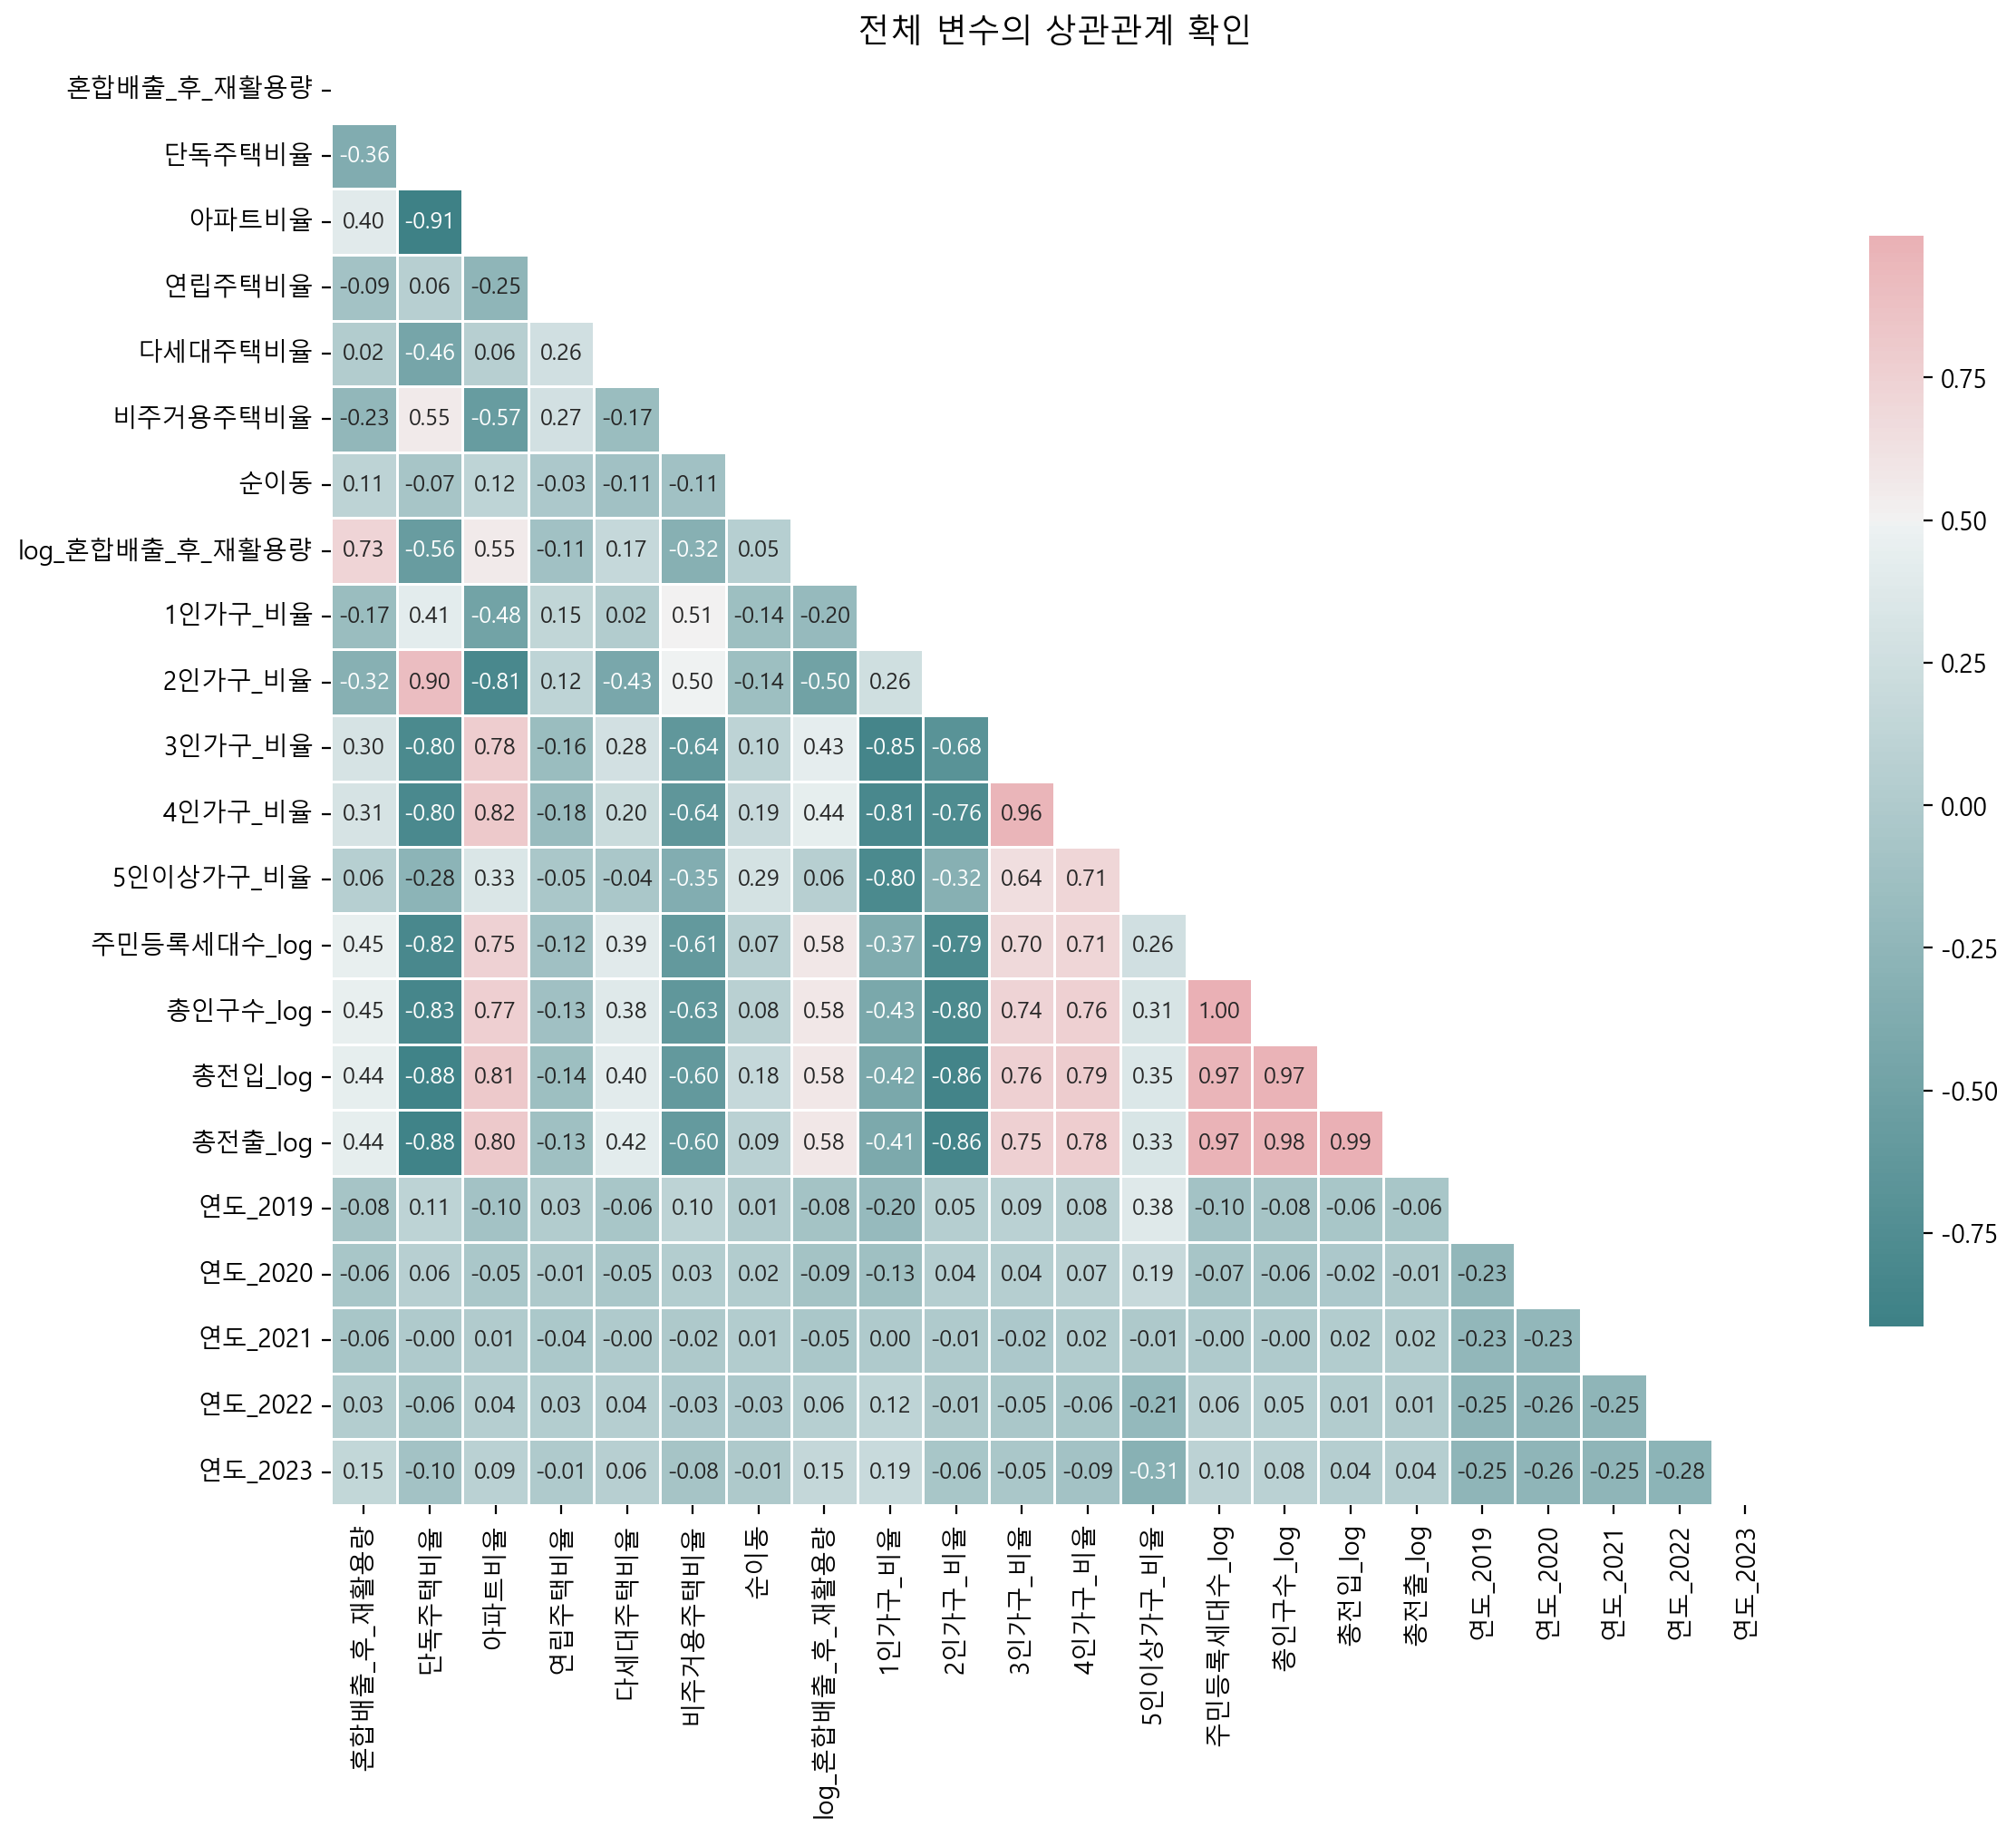

In [204]:
# 상관계수 계산
corr_matrix = merged_log[cols].corr()

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# heatmap
plt.figure(figsize=(12, 10))
cmap = sns.diverging_palette(200, 10, as_cmap=True)
sns.heatmap(corr_matrix, mask=mask,
            cmap=cmap, center=0.5,
            square=True, linewidths=0.5,
            annot=True, annot_kws={"size": 9}, 
            cbar_kws={"shrink": 0.75}, fmt=".2f",)

plt.title('전체 변수의 상관관계 확인', fontsize=13)
plt.xticks(rotation=90)
plt.tight_layout()

In [232]:
print(corr_matrix)

                 혼합배출_후_재활용량    단독주택비율     아파트비율    연립주택비율   다세대주택비율  \
혼합배출_후_재활용량         1.000000 -0.364333  0.398624 -0.094003  0.023338   
단독주택비율             -0.364333  1.000000 -0.913309  0.061600 -0.455897   
아파트비율               0.398624 -0.913309  1.000000 -0.253336  0.059762   
연립주택비율             -0.094003  0.061600 -0.253336  1.000000  0.264699   
다세대주택비율             0.023338 -0.455897  0.059762  0.264699  1.000000   
비주거용주택비율           -0.227534  0.552321 -0.573414  0.267636 -0.172779   
순이동                 0.114610 -0.065775  0.122789 -0.027981 -0.109650   
log_혼합배출_후_재활용량     0.725814 -0.557685  0.549891 -0.108794  0.170918   
1인가구_비율            -0.167890  0.414458 -0.483384  0.145347  0.021253   
2인가구_비율            -0.320612  0.896873 -0.812354  0.117944 -0.434858   
3인가구_비율             0.304939 -0.796950  0.776911 -0.163837  0.278730   
4인가구_비율             0.310245 -0.804394  0.817898 -0.184845  0.204396   
5인이상가구_비율           0.055140 -0.279899  0.334112 -0.046684 -0.04

- dv와 상관관계가 (아주) 높은 독립변수는 없는 거 같음
- 선형모델에서는 성능이 낮을 거 같다
- 랜덤포레스트랑 xgboost는 비선형모델이니까 일단 킵고잉

-  `총전입_log, 총전출_log, 총인구수_log, 세대수_log`와 같이 유동 인구와 관련된 변수와는 양의 상관관계
- `아파트비율`은 양의 상관관계, `단독주택비율`은 음의 상관관계

<br><br>

---
## 05. 선형회귀 모델 test

In [205]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import scipy.stats as stats

<br>

### 05-1. 일단 모든 변수에 대해 선형회귀 해보기

In [206]:
X = merged_log[['단독주택비율', '아파트비율', '연립주택비율', '다세대주택비율', '비주거용주택비율', '순이동',
                '1인가구_비율', '2인가구_비율', '3인가구_비율',  '4인가구_비율', '5인이상가구_비율',
                '주민등록세대수_log', '총인구수_log', '총전입_log', '총전출_log',
               '연도_2019', '연도_2020', '연도_2021', '연도_2022', '연도_2023']]
y = merged_log['log_혼합배출_후_재활용량']  # 종속변수 (로그 변환된 것)

In [207]:
# 데이터 분할 (8:2로)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [208]:
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

# 모델 학습
model = sm.OLS(y_train, X_train_const).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        log_혼합배출_후_재활용량   R-squared:                       0.435
Model:                            OLS   Adj. R-squared:                  0.412
Method:                 Least Squares   F-statistic:                     19.36
Date:                Sun, 22 Jun 2025   Prob (F-statistic):           2.02e-45
Time:                        04:29:49   Log-Likelihood:                -710.82
No. Observations:                 472   AIC:                             1460.
Df Residuals:                     453   BIC:                             1539.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        -133.8301    597.907     -0.224      0.823   -1308.847    1041.186
단독주택비율        176.5847    836.938      0.211      0.833   -1468.178    1821.348
아파트비율         177.6386    836.944      0.212      0.832   -1467.136    1822.414
연립주택비율        175.9237    837.125      0.210      0.834   -1469.207    1821.054
다세대주택비율       176.3516    836.971      0.211      0.833   -1468.476    1821.179
비주거용주택비율      204.5559    837.029      0.244      0.807   -1440.386    1849.498
순이동          3.982e-05   1.39e-05      2.855      0.005    1.24e-05    6.72e-05
1인가구_비율       -17.0894    119.528     -0.143      0.886    -251.988     217.809
2인가구_비율       -10.0320    119.468     -0.084      0.933    -244.812     224.748
3인가구_비율       -33.3437    120.035     -0.278      0.781    -269.237     202.550
4인가구_비율         3.3566    119.854      0.028      0.978    -232.182     238.895
5인이상가구_비율     -76.7215    120.508     -0.637      0.525    -313.546     160.103
주민등록세대수_log    -2.6598      3.268     -0.814      0.416      -9.083       3.763
총인구수_log        2.8161      3.312      0.850      0.396      -3.693       9.325
총전입_log        -1.6870      0.647     -2.606      0.009      -2.959      -0.415
총전출_log         2.2133      0.738      2.998      0.003       0.762       3.664
연도_2019       -26.6532    119.585     -0.223      0.824    -261.663     208.357
연도_2020       -26.8574    119.578     -0.225      0.822    -261.853     208.139
연도_2021       -26.9928    119.581     -0.226      0.822    -261.996     208.010
연도_2022       -26.7754    119.585     -0.224      0.823    -261.785     208.235
연도_2023       -26.5514    119.579     -0.222      0.824    -261.550     208.447
==============================================================================
Omnibus:                       47.075   Durbin-Watson:                   2.148
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               59.940
Skew:                          -0.780   Prob(JB):                     9.64e-14
Kurtosis:                       3.785   Cond. No.                     2.11e+20
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 4.29e-31. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

- 전반적인 설명력 R2: `0.435`
- `Prob (F-statistic)`가 0에 가까우므로 모델은 전체적으로 유의미
- 하지만 다중공선성이 매우매우 극단적으로 높음

<br>


### 05-2. 다중공선성 처리

In [209]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [210]:
# 다중공선성 확인
vif_data = pd.DataFrame()
vif_data["feature"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i)
                   for i in range(X_train.shape[1])]
vif_data

,feature,VIF
0,단독주택비율,1.771530e+07
1,아파트비율,1.507071e+07
2,연립주택비율,6.955304e+04
3,다세대주택비율,2.882017e+06
4,비주거용주택비율,1.289966e+04
5,순이동,2.966677e+00
6,1인가구_비율,inf
7,2인가구_비율,inf
8,3인가구_비율,inf
9,4인가구_비율,inf


<br>


### 05-3. 임의로 변수 제거 후 다시 선형회귀

In [225]:
X_new = merged_log[['총인구수_log', '아파트비율', '연도_2023']]
y = merged_log['log_혼합배출_후_재활용량']  # 종속변수 (로그 변환)

In [226]:
# 데이터 분할 (8:2로)
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=42)
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

# 모델 학습
model = sm.OLS(y_train, X_train_const).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        log_혼합배출_후_재활용량   R-squared:                       0.381
Model:                            OLS   Adj. R-squared:                  0.377
Method:                 Least Squares   F-statistic:                     95.85
Date:                Sun, 22 Jun 2025   Prob (F-statistic):           2.26e-48
Time:                        04:32:13   Log-Likelihood:                -732.43
No. Observations:                 472   AIC:                             1473.
Df Residuals:                     468   BIC:                             1489.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9007      0.829      1.087      0.278      -0.728       2.529
총인구수_log       0.5464      0.080      6.824      0.000       0.389       0.704
아파트비율          1.5309      0.346      4.426      0.000       0.851       2.211
연도_2023        0.3247      0.129      2.518      0.012       0.071       0.578
==============================================================================
Omnibus:                       51.593   Durbin-Watson:                   2.122
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               66.971
Skew:                          -0.831   Prob(JB):                     2.87e-15
Kurtosis:                       3.802   Cond. No.                         199.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [227]:
# 다중공선성 다시 확인
vif_data = pd.DataFrame()
vif_data["feature"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i)
                   for i in range(X_train.shape[1])]
vif_data

,feature,VIF
0,총인구수_log,8.863843
1,아파트비율,8.781084
2,연도_2023,1.289600


In [228]:
y_pred = model.predict(X_test_const)

# 성능 평가
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse:.2f}')
print(f'R²: {r2:.2f}')

MSE: 1.02
R²: 0.29


Text(0.5, 1.0, 'Residuals Histogram')

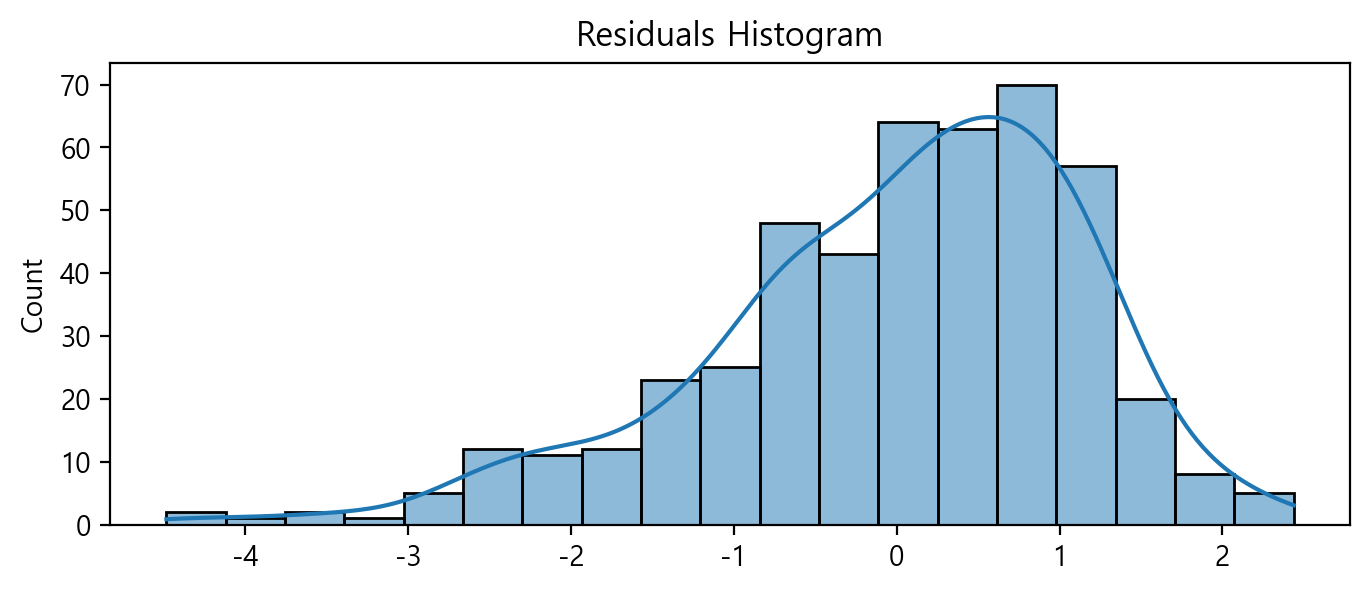

In [229]:
# 학습 데이터의 예측값
y_train_pred = model.predict(X_train_const)
residuals = y_train - y_train_pred

# 잔차 히스토그램
plt.figure(figsize=(8, 3))
sns.histplot(residuals, kde=True)
plt.title('Residuals Histogram')

Text(0.5, 1.0, 'Q-Q plot of residuals')

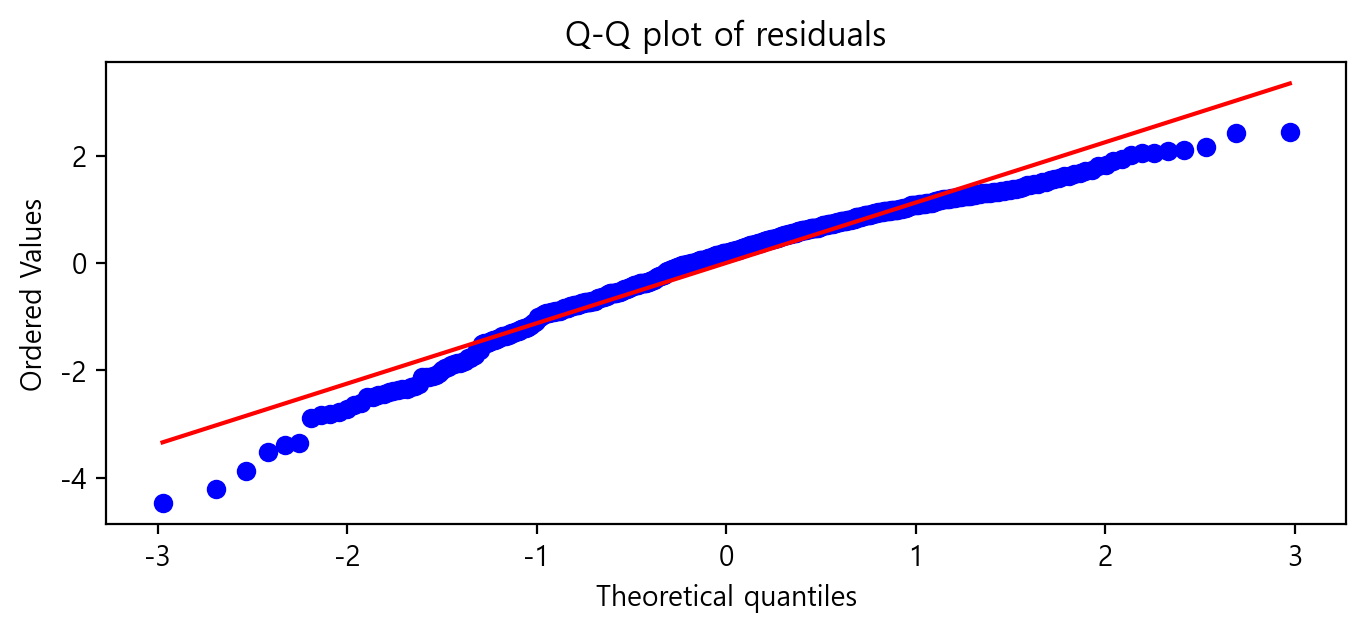

In [230]:
# Q-Q plot
plt.figure(figsize=(8, 3))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q plot of residuals")

### 선형 모델로 최적의 변수 조합을 찾는 건 시간이 댕많이 걸릴 것 같고 현재 가지고 있는 독립변수들은 서로 관련이 있으므로 그냥 바로 랜덤포레스트 가겠음 